In [23]:
# Input Image
# SET PYTHONPATH to the parent directory 
import os
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
import colorsys
# TODO: check this https://sassafras13.github.io/GumbelSoftmax/


plt.rc('text', usetex=True)
from einops import rearrange
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))

def complex_to_rgb(Z):
    mag = np.abs(Z)
    phase = np.angle(Z)
    norm_mag = mag / mag.max()
    
    hsv = np.zeros(Z.shape + (3,))
    hsv[..., 0] = (phase + np.pi) / (2*np.pi)   # hue
    hsv[..., 1] = 1.0                           # saturation
    hsv[..., 2] = norm_mag                      # value
    
    rgb = np.zeros_like(hsv)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            rgb[i,j] = colorsys.hsv_to_rgb(*hsv[i,j])
    return rgb

In [24]:
import numpy as np
from hippy2d.learnable import get_interpolation_weights, get_angle_samples_count, get_l2_neighbors, init_radial_part
from scipy.linalg import dft

N =  101
weights = get_interpolation_weights(fs=15,
                                    m=5,
                                    n_rings=3, 
                                    angle_samples=101)

def get_interpolation_weights(fs, m, n_rings, angle_samples):
    """
    Used to construct the steerable filters using Radial basis functions.
    The filters are constructed on the patches of n_rings using Gaussian
    interpolation. (Code adapted from the tf code of Worrall et al., CVPR, 2017)

    Args:
        fs (int): filter size for the H-net convolutional layer
        m (int): max. rotation order for the steerable filters
        n_rings (int): No. of rings for the steerable filters
        angle_samples (int): No. of angle samples

    Returns:
        norm_weights (numpy): contains normalized weights for interpolation
        using the steerable filters
    """

    mid = int(np.floor(fs / 2))
    # Variance of Gaussian resampling
    std_gauss = (mid / n_rings) / 2
    # We define below radii up to n_rings-0.5 (as in Worrall et al, CVPR 2017)
    radii = np.linspace(m != 0, mid - 2 * std_gauss, n_rings)
    print(radii)
    # We define pixel centers to be at positions 0.5
    center_pt = np.asarray([fs, fs]) / 2.

    # Extracting the set of angles to be sampled

    # Choosing the sampling locations for the rings
    lin = (2 * np.pi * np.arange(angle_samples)) / angle_samples
    ring_locations = np.vstack([-np.sin(lin), np.cos(lin)])

    # Create interpolation coefficient coordinates
    coords = get_l2_neighbors(center_pt, fs)

    # getting samples based on the chosen center_pt and the coords
    radii = radii[:, np.newaxis, np.newaxis, np.newaxis]
    ring_locations = ring_locations[np.newaxis, :, :, np.newaxis]
    diff = radii * ring_locations - coords[np.newaxis, :, np.newaxis, :]
    dist2 = np.sum(diff ** 2, axis=1)

    # Convert distances to weightings
    weights = np.exp(-0.5 * dist2 / (std_gauss ** 2))  # For bandwidth of 0.5

    # Normalizing the weights to calibrate the different steerable filters
    norm = np.sum(weights,
                  axis=2,
                  keepdims=True)
    assert np.all(norm != 0), "Normalizing by zero weights"
    return np.divide(weights,
                     norm,
                     where=(norm != 0))



def get_cosmsin_order(order: float, N: int):
    samples = order * np.linspace(0, 2*np.pi, num=N+1)[:-1]
    return np.cos(samples) + 1j * np.sin(samples)

def get_low_pass_filter(kernel_size, orders, n_rings):
    N = get_angle_samples_count(kernel_size)
    weights2filter_sampler = []
    for order in orders:
        weights = get_interpolation_weights(kernel_size,
                                            m=order,
                                            n_rings=n_rings,
                                            angle_samples=N)
        low_pass_filter = np.dot(get_cosmsin_order(order, N), weights).T
        weights2filter_sampler.append(
                torch.from_numpy(low_pass_filter))
    return torch.stack(weights2filter_sampler)

In [25]:
in_channels = 1 
out_channels = 1
ring_count = 3
kernel_size = 15
orders = [0.5, 1.0]


radial_weights = init_radial_part(in_channels, 
                              out_channels,
                              orders=orders,
                              ring_count=ring_count)
radial_weights = torch.ones_like(radial_weights) 
angular_part = get_low_pass_filter(kernel_size,
                                   orders=orders,
                                   n_rings=ring_count)
# Construct the filters
filters = rearrange(torch.matmul(angular_part, radial_weights.to(torch.complex128)),
              pattern="o (h w) (ic oc) -> o oc ic h w",
              h=kernel_size,
              w=kernel_size,
              ic=in_channels,
              oc=out_channels)

[1.         2.83333333 4.66666667]
[1.         2.83333333 4.66666667]


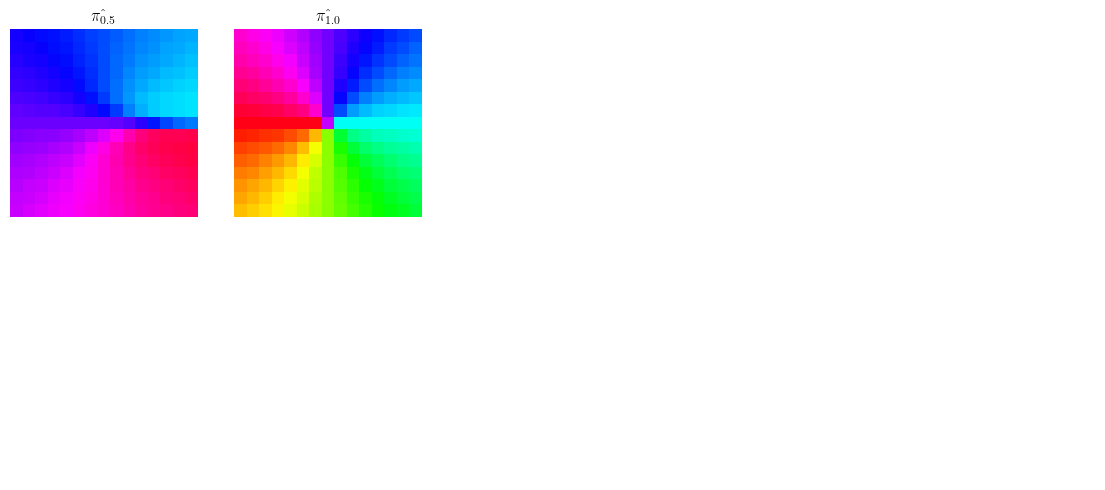

In [26]:
import matplotlib.pyplot as plt
# Plot all the filters
fig, axes = plt.subplots(2, 5, figsize=(14, 6)) 
for i, ax in enumerate(axes.flat):
    if i < filters.shape[0]:
        filter = filters[i][0][0].detach()
        ax.imshow(filter.angle(), cmap='hsv', vmin=-np.pi, vmax=np.pi)
        ax.set_title(f'$\hat{{\pi_{{{orders[i]}}}}}$')
    ax.axis('off')

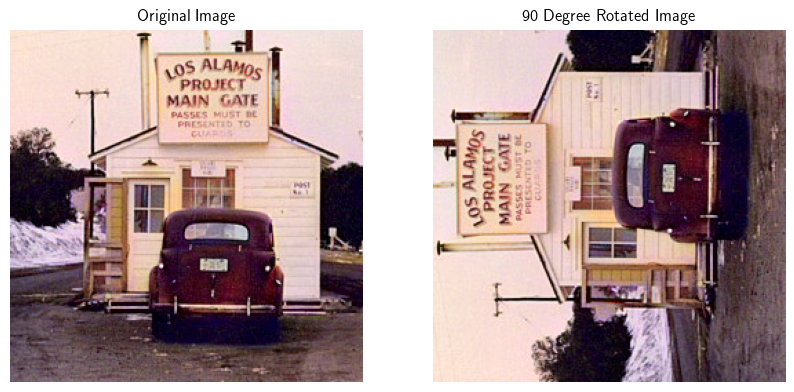

In [27]:
# Testing images
import torch 
from torchvision import transforms
from hippy2d.utils import get_testing_img, get_default_complex
# Set default to double precision
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simulate RGB channels
test_img = get_testing_img(rgb=False)
test_img = transforms.ToTensor()(test_img).to(dtype=torch.float64)
rotated_img = torch.rot90(test_img, 1, [1, 2])
# 
test_rgb_img = get_testing_img(rgb=True)
test_rgb_img = transforms.ToTensor()(test_rgb_img).to(dtype=torch.float64)
rotated_rgb_img = torch.rot90(test_rgb_img, 1, [1, 2])
# Plot the images
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_rgb_img.permute(1, 2, 0).numpy())
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rotated_rgb_img.permute(1, 2, 0).numpy())
plt.title("90 Degree Rotated Image",)
plt.axis('off')
plt.show()


In [28]:
_filters = rearrange(filters, 'o oc ic h w -> (o oc) ic h w')
output = torch.conv2d(input=test_img.to(torch.complex128).unsqueeze(0),
                      weight=_filters)
#output = rearrange(output, 'b (m out) h w -> b m out h w')
output_rot = torch.conv2d(input=rotated_img.to(torch.complex128).unsqueeze(0),
                          weight=_filters)
output = rearrange(output, 'b (m out) h w -> b m out h w', m=len(orders))[0]
output_rot = rearrange(output_rot, 'b (m out) h w -> b m out h w', m=len(orders))[0]

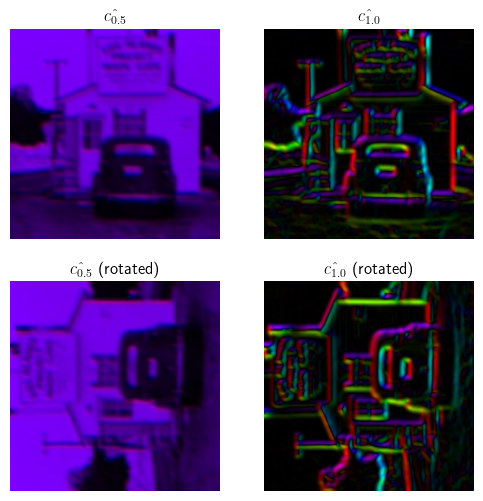

In [29]:
# plot the outputs in complex
OUTPUT_CHANNEL = 0
# plot all the channels
fig, axs = plt.subplots(2, output.shape[0], figsize=(6, 6))

for idx, ax in enumerate(axs[0].flat):
        ax.imshow(complex_to_rgb(output[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$')
for idx, ax in enumerate(axs[1].flat):
        ax.imshow(complex_to_rgb(output_rot[idx][OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        ax.set_title(f'$\hat{{c_{{{orders[idx]}}}}}$ (rotated)')

Text(0.5, 1.0, '$\\hat{c_{0.5}}$ (rotated)')

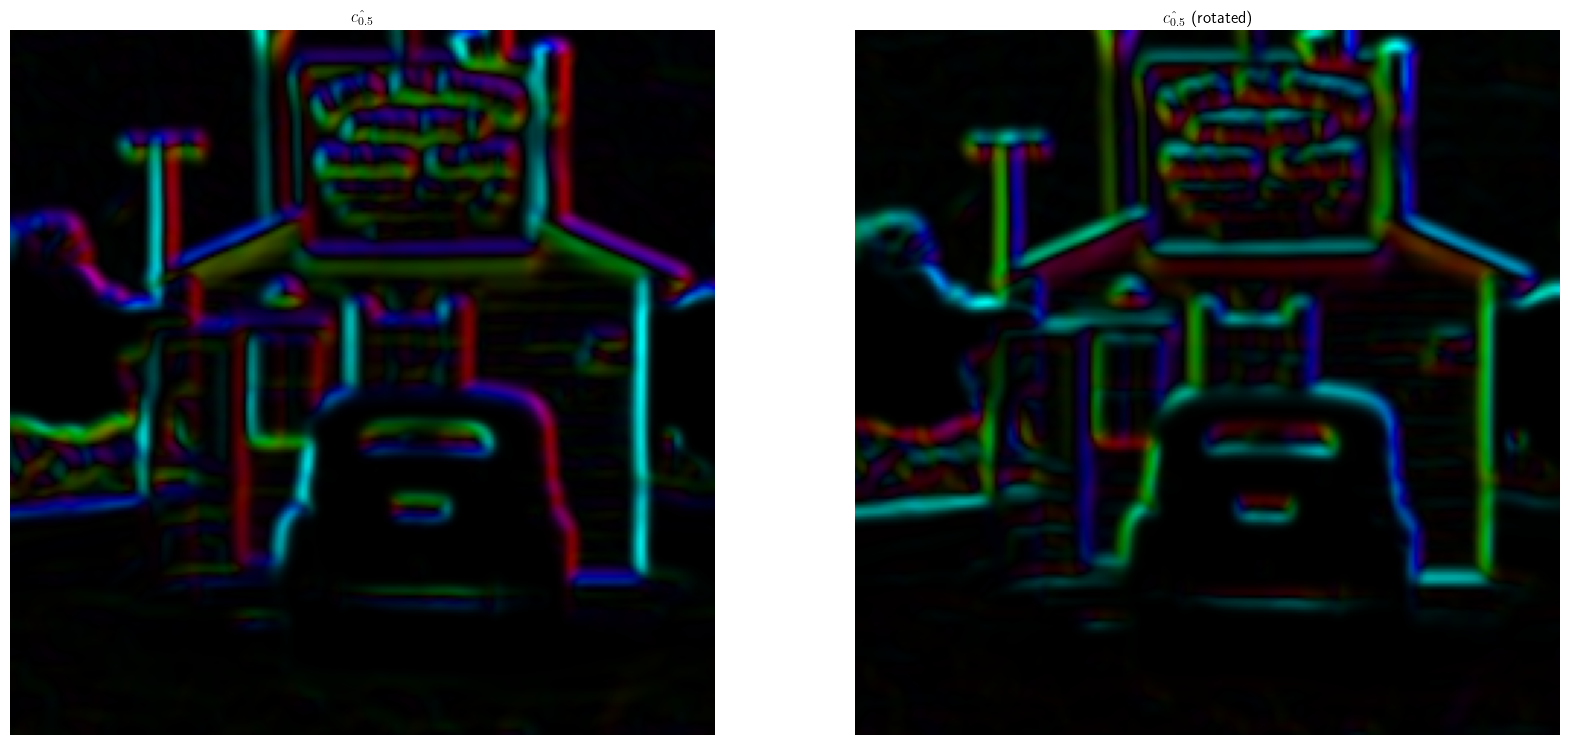

In [47]:
# plot all the channels
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(complex_to_rgb(invariants[OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
axs[0].axis('off')
axs[0].set_title(f'$\hat{{c_{{{orders[0]}}}}}$')

axs[1].imshow(complex_to_rgb(torch.rot90(invariants_rot[OUTPUT_CHANNEL].detach(), k=-1, dims=[-2, -1]).numpy()), cmap='hsv')
axs[1].axis('off')
axs[1].set_title(f'$\hat{{c_{{{orders[0]}}}}}$ (rotated)')

In [ ]:
knorm_factor = output[1].conj()
real_moment = output[0]

rot_norm_factor = output_rot[1].conj()
rot_real_moment = output_rot[0]

invariants = real_moment ** 2 * norm_factor
invariants_rot = rot_real_moment ** 2 * rot_norm_factor




In [ ]:
# plot invariants
fig, axs = plt.subplots(2, 1, figsize=(26, 5))
for idx, ax in enumerate([axs[0]]):
        ax.imshow(complex_to_rgb(invariants[OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        #ax.set_title(f'$i_{{{orders[idx+3]}}}$') 
for idx, ax in enumerate([axs[1]]):
        ax.imshow(complex_to_rgb(invariants_rot[OUTPUT_CHANNEL].detach().numpy()), cmap='hsv')
        ax.axis('off')
        #ax.set_title(f'$i_{{{orders[idx+3]}}}$ (rotated)')

# Assert the invariants are rotation invariant
assert torch.allclose(invariants, torch.rot90(invariants_rot, k=-1,dims=[-2, -1]))
# Asssert copies are also rotation invariant
assert torch.allclose(invariants_copy, torch.rot90(invariants_rot_copy, k=-1,dims=[-2, -1])), "Invariants with copy are not rotation invariant"

SyntaxError: unmatched ')' (2044616082.py, line 13)

In [ ]:
import torch.nn.functional as F

def gumbel_soft_round(x, tau=1.0):
    # Assume rounding to nearest integer 0 or 1
    logits = torch.stack([1 - x, x], dim=-1)
    probs = F.gumbel_softmax(logits,  hard=True)
    return probs[..., 1]

In [ ]:
gumbel_soft_round(torch.tensor(0.49), tau=0.01)

tensor(0.)

In [ ]:
import torch
import torch.nn.functional as F

def gumbel_soft_round_5(logits, tau=1.0, hard=True):
    y = F.gumbel_softmax(logits, tau=tau, hard=hard)
    values = torch.arange(5.0, device=logits.device)
    return (y * values).sum(-1)

# Example
logits = torch.randn(3, 5, requires_grad=True)
y = gumbel_soft_round_5(logits, tau=0.5, hard=True)

print("Discrete values:", y)


Discrete values: tensor([2., 3., 0.], grad_fn=<SumBackward1>)
